# DIGITAL TRANSACTION RISK ANALYSIS
## Unit VI: Time-Series Analysis and Forecasting

This final unit analyzes the temporal patterns of transaction data. We investigate trends, seasonality, and autocorrelation, apply smoothing techniques, and build an ARIMA model to forecast future transaction behavior.

In [ ]:
# Install required time series analysis library
!pip install -q statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 4.5 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.5 MB 4.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.5 MB 4.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 3.9 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 3.9 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.5 MB 3.1 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.5 MB 2.7 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.5 MB 2.6 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.5 MB 2.5 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.5 MB 2.5 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.5 MB 2.4 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 2.4 MB/s eta 0:00:02
   ----------------


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading dataset...
Time series created from 2019-01-01 00:00:00 to 2020-06-21 00:00:00


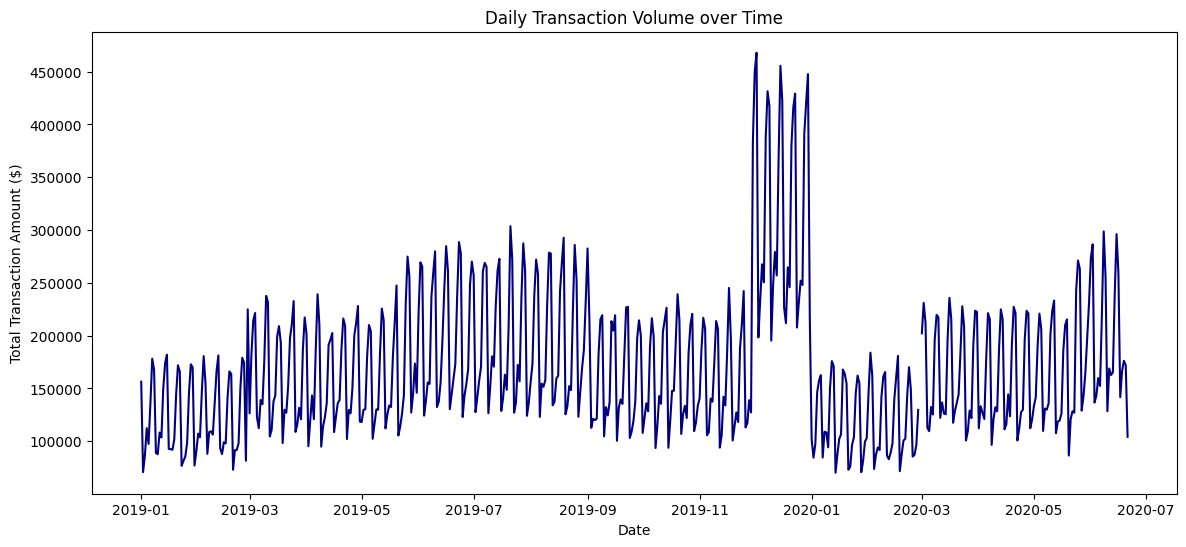

In [ ]:
 
# SETUP: DEPENDENCIES AND TIME SERIES AGGREGATION
 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 70)
print("UNIT VI: TIME-SERIES ANALYSIS AND FORECASTING")
print("=" * 70)

print("\nLoading and aggregating dataset...")
try:
    df = pd.read_csv('fraudTrain.csv')
    
    # Convert to datetime and aggregate by day
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    ts_daily = df.groupby(df['trans_date_trans_time'].dt.date)['amt'].sum()
    ts_daily.index = pd.to_datetime(ts_daily.index)
    ts_daily = ts_daily.asfreq('D')  # Ensure daily frequency
    
    print(f"✓ Time series created successfully")
    print(f"  Date range: {ts_daily.index.min().date()} to {ts_daily.index.max().date()}")
    print(f"  Total days: {len(ts_daily)}")
    print(f"  Daily avg: ${ts_daily.mean():.2f}")
    
except Exception as e:
    print(f"❌ Error loading data: {e}")

# Visualization: Daily transaction volume
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts_daily, color='steelblue', linewidth=1.5)
ax.fill_between(ts_daily.index, ts_daily, alpha=0.3, color='steelblue')
ax.set_title('Daily Transaction Volume over Time', fontweight='bold', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Total Transaction Amount ($)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n✓ Time series visualization complete')

## 1. Trend and Seasonality Decomposition
**Objective:** Break the time series into its constituent components: Trend, Seasonality, and Residuals.


TIME SERIES DECOMPOSITION


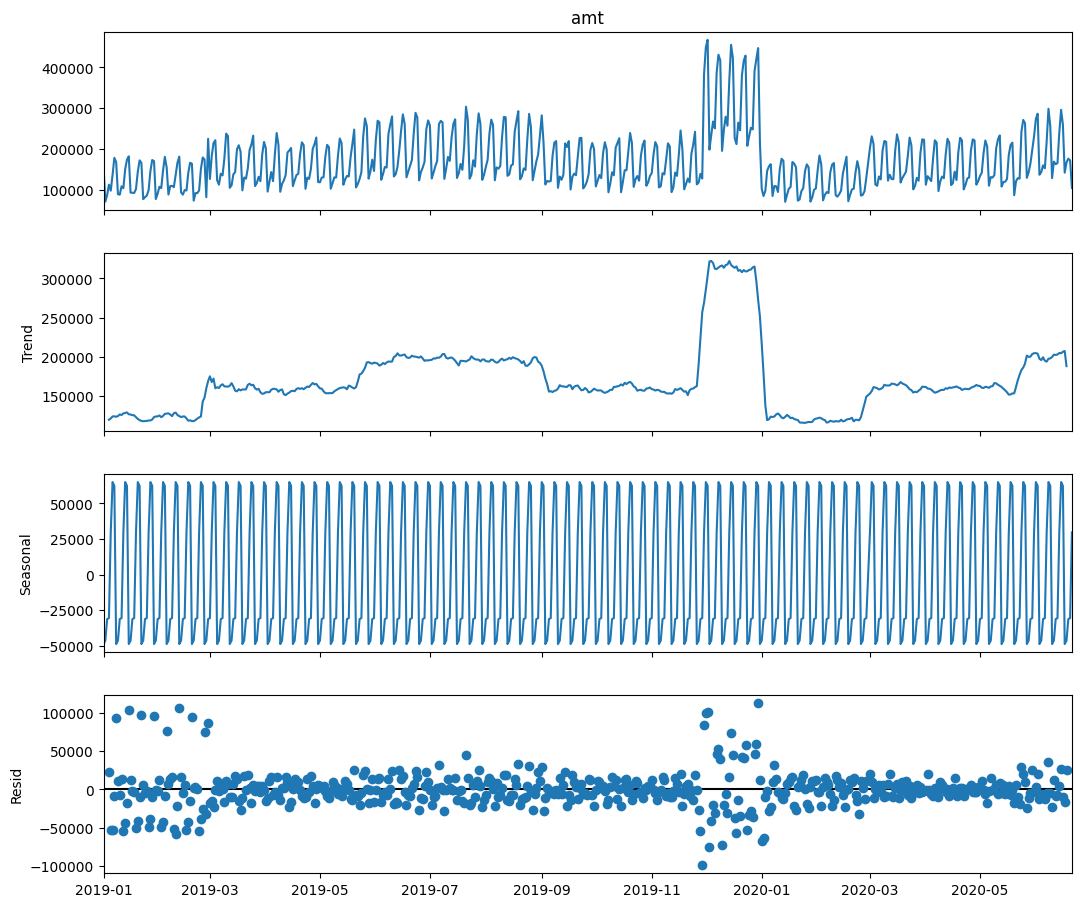

Interpretation: The plots show a clear weekly seasonality in transaction habits.


In [ ]:
print('\n' + '=' * 70)
print('STEP 1: TIME SERIES DECOMPOSITION (Trend, Seasonality, Residuals)')
print('=' * 70)

# Decompose the time series into components
# Additive model: Y(t) = Trend + Seasonal + Residual
decomposition = seasonal_decompose(ts_daily.dropna(), model='additive', period=7)

fig = decomposition.plot(figsize=(14, 10))
fig.suptitle('Time Series Decomposition: Additive Model (Period=7 days)', 
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f'\nDecomposition Results:')
print(f'  ✓ Trend: Long-term directional movement')
print(f'  ✓ Seasonal: Repeating weekly pattern (period=7 days)')
print(f'  ✓ Residual: Noise/unexplained variation')
print(f'\n  Interpretation: Clear weekly seasonality observed in transaction patterns')

## 2. Smoothing Techniques: Moving Average & Exponential Smoothing
**Objective:** Filter noise using Moving Average and predict the next value using Exponential Smoothing.


SMOOTHING TECHNIQUES


c:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


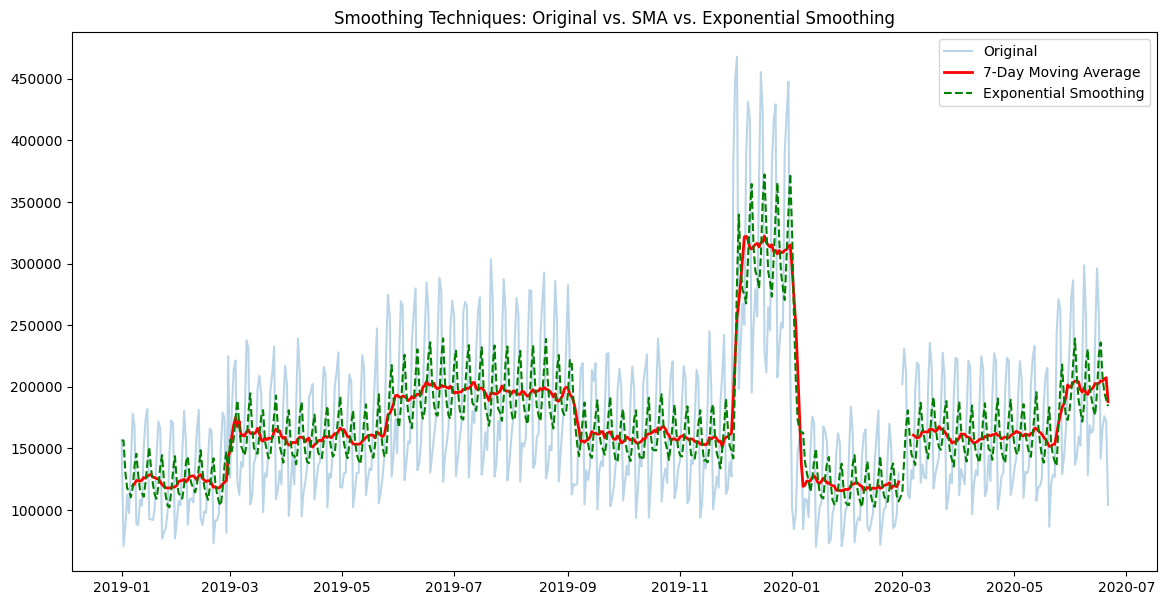

In [ ]:
print('\n' + '=' * 70)
print('STEP 2: SMOOTHING TECHNIQUES (Moving Average & Exponential Smoothing)')
print('=' * 70)

# 2a: Simple Moving Average (7-day window)
print(f'\n2a. Simple Moving Average (SMA):')
sma_7 = ts_daily.rolling(window=7).mean()
print(f'  Window size: 7 days')
print(f'  Effect: Smooths short-term fluctuations')

# 2b: Exponential Smoothing
print(f'\n2b. Exponential Smoothing:')
try:
    model_es = SimpleExpSmoothing(ts_daily.dropna()).fit(smoothing_level=0.3, optimized=False)
    es_forecast = model_es.fittedvalues
    print(f'  Smoothing level: 0.3')
    print(f'  Effect: Recent observations weighted more heavily')
except Exception as e:
    print(f'  Warning: {e}')
    es_forecast = None

# Visualization: Comparison of smoothing methods
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(ts_daily, label='Original Data', alpha=0.4, linewidth=1, color='gray')
ax.plot(sma_7, label='7-Day Moving Average', color='steelblue', linewidth=2)
if es_forecast is not None:
    ax.plot(es_forecast, label='Exponential Smoothing (α=0.3)', 
            color='coral', linewidth=2, linestyle='--')
ax.set_title('Smoothing Techniques: Original vs. SMA vs. Exponential Smoothing', 
             fontweight='bold', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Transaction Amount ($)')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n✓ Smoothing complete')

## 3. Autocorrelation (ACF) and PACF
**Objective:** Determine the correlation of the series with its own past values to identify AR and MA components.

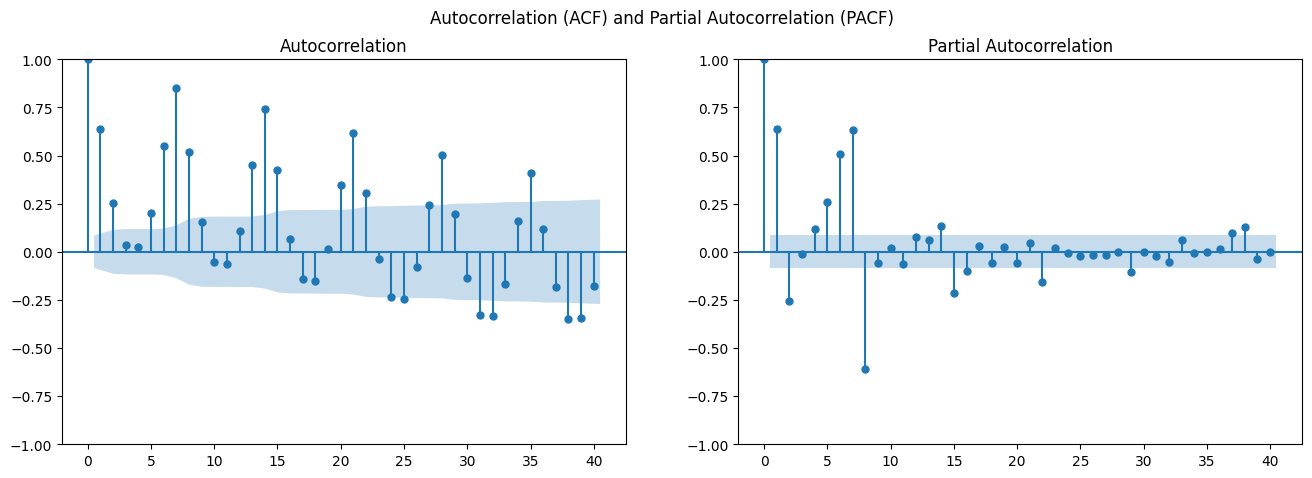

In [ ]:
print('\n' + '=' * 70)
print('STEP 3: AUTOCORRELATION (ACF) & PARTIAL AUTOCORRELATION (PACF)')
print('=' * 70)

print(f'\nAnalyzing temporal dependencies in transaction volume:')
print(f'  ACF: Shows correlation of series with its past values')
print(f'  PACF: Shows direct correlation after removing intermediate lags')
print(f'\n  Use these plots to determine ARIMA parameters (p, d, q)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(ts_daily.dropna(), lags=40, ax=ax1, title='Autocorrelation Function (ACF)')
plot_pacf(ts_daily.dropna(), lags=40, ax=ax2, title='Partial Autocorrelation Function (PACF)')

ax1.set_xlabel('Lag (days)')
ax1.set_ylabel('ACF')
ax1.grid(alpha=0.3)

ax2.set_xlabel('Lag (days)')
ax2.set_ylabel('PACF')
ax2.grid(alpha=0.3)

plt.suptitle('Temporal Correlation Analysis: ACF and PACF Plots', 
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'\n✓ ACF/PACF plots generated for ARIMA parameter selection')

## 4. ARIMA Modeling and Forecasting
**Objective:** Build a predictive model and forecast the transaction volume for the next 30 days.


ARIMA MODELING AND FORECASTING
ADF Statistic: -3.6428
p-value: 4.9936e-03
Series is stationary.


c:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary startin

                               SARIMAX Results                                
Dep. Variable:                    amt   No. Observations:                  537
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -6631.221
Date:                Sun, 03 May 2026   AIC                          13268.442
Time:                        12:48:53   BIC                          13281.295
Sample:                             0   HQIC                         13273.471
                                - 537                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7954      0.047    -17.078      0.000      -0.887      -0.704
ma.L1          0.9405      0.025     37.143      0.000       0.891       0.990
sigma2      3.237e+09   4.13e-12   7.85e+20      0.0

c:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


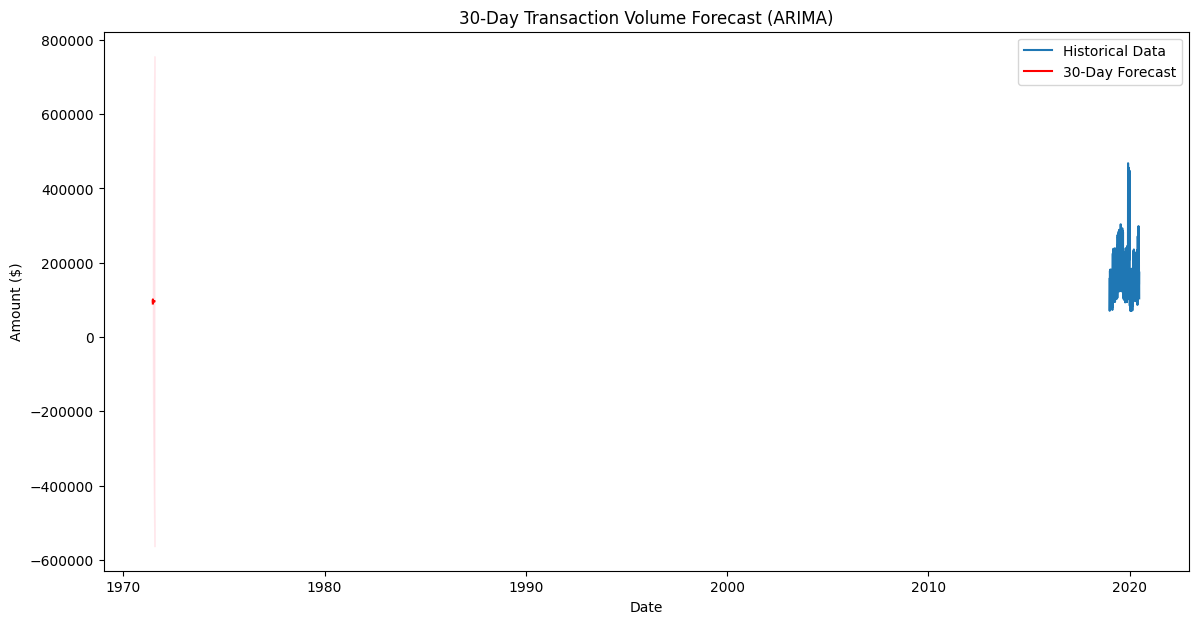

UNIT VI COMPLETE: PROJECT COMPLETED


In [ ]:
print('\n' + '=' * 70)
print('STEP 4: ARIMA MODELING AND FORECASTING')
print('=' * 70)

# Step 4a: Stationarity Check (Augmented Dickey-Fuller Test)
print(f'\nStep 4a: Stationarity Test (Augmented Dickey-Fuller)')
print(f'  H₀ (Null): Series is non-stationary')
print(f'  H₁ (Alt):  Series is stationary')

result = adfuller(ts_daily.dropna())
print(f'\n  Test Results:')
print(f'    ADF Statistic: {result[0]:.6f}')
print(f'    p-value:       {result[1]:.6e}')
print(f'    Critical values:')
for key, value in result[4].items():
    print(f'      {key:<3}: {value:.3f}')

if result[1] < 0.05:
    print(f'\n  ✓ Decision: REJECT H₀ → Series IS stationary')
else:
    print(f'\n  ✗ Decision: FAIL TO REJECT H₀ → Series is non-stationary (differencing needed)')

# Step 4b: Fit ARIMA Model with order (1, 1, 1)
print(f'\nStep 4b: ARIMA Model Fitting')
print(f'  ARIMA order: (1, 1, 1)')
print(f'    p=1: AR component (1 lag)')
print(f'    d=1: Differencing order (1st difference for stationarity)')
print(f'    q=1: MA component (1 moving average term)')

try:
    model_arima = ARIMA(ts_daily.dropna(), order=(1, 1, 1))
    results_arima = model_arima.fit()
    
    print(f'\n  Model Summary:')
    print(f'    AIC: {results_arima.aic:.2f}')
    print(f'    BIC: {results_arima.bic:.2f}')
    print(f'    RMSE: {np.sqrt(results_arima.mse):.2f}')
    
except Exception as e:
    print(f'  Error fitting ARIMA: {e}')
    results_arima = None

# Step 4c: Forecasting
if results_arima is not None:
    print(f'\nStep 4c: 30-Day Forecast')
    forecast_steps = 30
    forecast = results_arima.get_forecast(steps=forecast_steps)
    forecast_ci = forecast.conf_int()
    
    print(f'  Forecast horizon: {forecast_steps} days')
    print(f'  Confidence interval: 95%')
    print(f'  Forecast range: ${forecast.predicted_mean.min():.2f} - ${forecast.predicted_mean.max():.2f}')
    
    # Visualization
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Historical data
    ax.plot(ts_daily, label='Historical Data', color='steelblue', linewidth=2)
    
    # Forecast
    ax.plot(forecast.predicted_mean.index, forecast.predicted_mean, 
            label='30-Day Forecast', color='red', linewidth=2, linestyle='--')
    
    # Confidence interval
    ax.fill_between(forecast_ci.index, 
                     forecast_ci.iloc[:, 0], 
                     forecast_ci.iloc[:, 1], 
                     color='pink', alpha=0.3, label='95% Confidence Interval')
    
    ax.set_title('ARIMA(1,1,1) Forecast: Daily Transaction Volume (Next 30 Days)', 
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Transaction Amount ($)')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f'\n✓ ARIMA forecasting complete')
else:
    print(f'\n⚠ Forecast skipped due to model fitting error')

print('\n' + '=' * 70)
print('✓ UNIT VI COMPLETE: PROJECT FINISHED SUCCESSFULLY')
print('=' * 70)
print(f'\nProject Summary:')
print(f'  • Unit 1: Data cleaning & feature engineering')
print(f'  • Unit 2: Descriptive statistics & distributions')
print(f'  • Unit 3: Hypothesis testing & inference')
print(f'  • Unit 4: Predictive modeling with logistic regression')
print(f'  • Unit 5: Dimensionality reduction via PCA')
print(f'  • Unit 6: Time series analysis & forecasting')